### Data analysis in astronomy at NTU 

Week 5

Ting-Wen Lan 

Cross-correlation

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
### https://www.dropbox.com/s/oo9o50jjebjjpor/simple_correlation_100_x_y.npy?dl=0
### https://www.dropbox.com/s/huiy2baip8z68ca/simple_correlation_1000_x_y.npy?dl=0
### https://www.dropbox.com/s/ew850eai3gkk4st/simple_correlation_10000_x_y.npy?dl=0

In [33]:
def importdata(path):
    data = np.load(path)
    x = data[0,:]
    y = data[1,:]
    return data, x, y

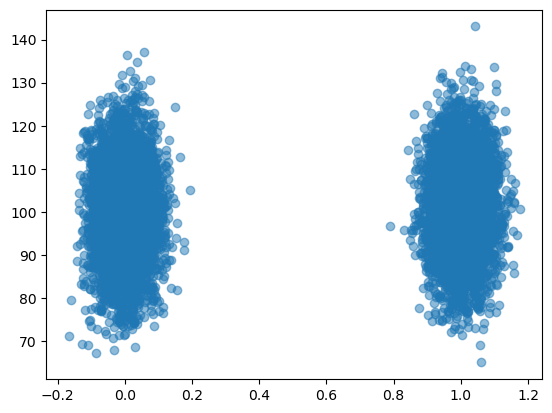

In [28]:
plt.scatter(x+np.random.normal(0,0.05,len(x)),y,alpha=0.5)
#plt.scatter(x,y)

### 1. Write a simple function to calculate the y_0,mean(y) when x==0 and the y_1, mean(y) when x==1
### 2. dy = mean(y_1) - mean(y_0)
### 3. Estimate the uncertainty of dy with error propagation
### 4. Estimate the uncertainty of dy with bootstrap

In [34]:
def calculate_means_and_dy(x, y):
    y_0 = []
    y_1 = []
    for i in range(len(y)):
        if x[i] == 0:
            y_0.append(y[i])
        elif x[i] == 1:
            y_1.append(y[i])

    y_0_mean = np.mean(y_0)
    y_1_mean = np.mean(y_1)

    dy = y_1_mean - y_0_mean
    return y_0, y_1, y_0_mean, y_1_mean, dy


y_0, y_1, y_0_mean, y_1_mean, dy = calculate_means_and_dy(x, y)
print(dy)

0.9629996703356767


In [35]:
def estimate_uncertainty_error_propagation(y_0, y_1):
    # Calculate standard deviations
    sigma_y_0 = np.std(y_0, ddof=1)
    sigma_y_1 = np.std(y_1, ddof=1)

    # Calculate number of elements
    n_0 = len(y_0)
    n_1 = len(y_1)

    err1 = (sigma_y_0 / np.sqrt(n_0))**2
    err2 = (sigma_y_1 / np.sqrt(n_1))**2

    # Calculate uncertainty of dy
    sigma_dy = np.sqrt(err1 + err2)
    return sigma_dy

# Example usage
sigma_dy = estimate_uncertainty_error_propagation(y_0, y_1)
print(sigma_dy)

0.20037066319392796


In [36]:
def estimate_uncertainty_bootstrap(y_0, y_1, n_bootstrap=1000):
    
    # Array to store dy values from bootstrap samples
    dy_bootstrap = np.zeros(n_bootstrap)

    # Perform bootstrap sampling
    for i in range(n_bootstrap):
        # Resample y_0 and y_1 with replacement
        y_0_resample = np.random.choice(y_0, size=len(y_0), replace=True)
        y_1_resample = np.random.choice(y_1, size=len(y_1), replace=True)

        # Calculate mean values for resampled data
        y_0_mean_resample = np.mean(y_0_resample)
        y_1_mean_resample = np.mean(y_1_resample)

        # Calculate dy for resampled data
        dy_bootstrap[i] = y_1_mean_resample - y_0_mean_resample

    # Estimate the uncertainty of dy as the standard deviation of bootstrap samples
    sigma_dy_bootstrap = np.std(dy_bootstrap)
    return sigma_dy_bootstrap

# Example usage
sigma_dy_bootstrap = estimate_uncertainty_bootstrap(y_0, y_1, n_bootstrap=1000)
print(sigma_dy_bootstrap)

0.20700610341466946


In [39]:

# Define the paths to the data files
path1 = 'simple_correlation_10000_x_y.npy'
path2 = 'simple_correlation_1000_x_y.npy'
path3 = 'simple_correlation_100_x_y.npy'

# Import the data from the first path
data1, x1, y1 = importdata(path1)

# Import the data from the second path
data2, x2, y2 = importdata(path2)

# Import the data from the third path
data3, x3, y3 = importdata(path3)


# Step 1: Calculate means and dy for each dataset
y_0_1, y_1_1, y_0_mean_1, y_1_mean_1, dy_1 = calculate_means_and_dy(x1, y1)
y_0_2, y_1_2, y_0_mean_2, y_1_mean_2, dy_2 = calculate_means_and_dy(x2, y2)
y_0_3, y_1_3, y_0_mean_3, y_1_mean_3, dy_3 = calculate_means_and_dy(x3, y3)

# Step 2: Estimate the uncertainty of dy with error propagation for each dataset
sigma_dy_1 = estimate_uncertainty_error_propagation(y_0_1, y_1_1)
sigma_dy_2 = estimate_uncertainty_error_propagation(y_0_2, y_1_2)
sigma_dy_3 = estimate_uncertainty_error_propagation(y_0_3, y_1_3)

# Step 3: Estimate the uncertainty of dy with bootstrap for each dataset
sigma_dy_bootstrap_1 = estimate_uncertainty_bootstrap(y_0_1, y_1_1, n_bootstrap=1000)
sigma_dy_bootstrap_2 = estimate_uncertainty_bootstrap(y_0_2, y_1_2, n_bootstrap=1000)
sigma_dy_bootstrap_3 = estimate_uncertainty_bootstrap(y_0_3, y_1_3, n_bootstrap=1000)

# Step 4: Print the results
print(f"Dataset 1: dy = {round(dy_1, 2)}, sigma_dy = {round(sigma_dy_1, 2)}, sigma_dy_bootstrap = {round(sigma_dy_bootstrap_1, 2)}")
print(f"Dataset 2: dy = {round(dy_2, 2)}, sigma_dy = {round(sigma_dy_2, 2)}, sigma_dy_bootstrap = {round(sigma_dy_bootstrap_2, 2)}")
print(f"Dataset 3: dy = {round(dy_3, 2)}, sigma_dy = {round(sigma_dy_3, 2)}, sigma_dy_bootstrap = {round(sigma_dy_bootstrap_3, 2)}")

Dataset 1: dy = 0.96, sigma_dy = 0.2, sigma_dy_bootstrap = 0.2
Dataset 2: dy = 0.78, sigma_dy = 0.62, sigma_dy_bootstrap = 0.62
Dataset 3: dy = -0.55, sigma_dy = 2.02, sigma_dy_bootstrap = 2.01
